### Inläsning och förståelse av data (Kodblock 1)

Arbetet inleddes med att läsa in MNIST-datasetet via fetch_openml. Datasetet består av 70 000 observationer där varje bild representeras av 784 pixlar (28x28). 
I detta steg kontrollerade jag datans dimensioner och konverterade målvariabeln till numeriskt format.
Det var viktigt för mig att säkerställa att datan var korrekt formaterad innan jag gick vidare, eftersom fel i detta tidiga skede ofta leder till svårtolkade problem senare i processen.

### Uppdelning av data (Kodblock 2)

Därefter delade jag upp datasetet i tränings-, validerings- och testmängd. 
Jag valde att använda tre delmängder för att kunna: träna modeller på träningsdata, välja modell och optimera parametrar på valideringsdata, göra en slutlig, opartisk utvärdering på testdata.
Jag använde stratifiering för att säkerställa att fördelningen av siffrorna 0–9 blev jämn i alla delmängder. 
Detta minskar risken att modellen tränas på en skev klassfördelning. Detta steg var centralt för att arbeta enligt en korrekt maskininlärningsprocess och undvika dataläckage.

### Skalning av data (Kodblock 3)

Eftersom vissa modeller, särskilt Logistic Regression, är känsliga för skalan på indata standardiserade jag features med StandardScaler (se Kodblock 3). 
Jag anpassade skalaren (fit) enbart på träningsdata och applicerade sedan transformationen (transform) på validerings- och testdata. 
Detta gjordes för att undvika dataläckage och säkerställa att ingen information från val- eller testdata påverkade träningen. 
Detta steg tydliggjorde för mig hur viktigt det är att separera träning och utvärdering även i preprocessing-fasen.

### Träning av kandidater (Kodblock 4)

I nästa steg tränade jag fyra olika modeller:
- Logistic Regression
- Random Forest
- Extra Trees
- Voting Classifier

Samtliga modeller tränades enbart på träningsdatan. I detta kodblock genomfördes ingen utvärdering, utan syftet var att skapa tränade kandidater inför jämförelsen. 
Genom att tydligt separera träning och utvärdering blev processen mer strukturerad och lättare att följa.

### Modellutvärdering på valideringsdata (Kodblock 5)

Efter träningen utvärderade jag modellerna på valideringsmängden (se Kodblock 5). Jag använde flera mått:

 - Accuracy
 - Precision (macro)
 - Recall (macro)
 - F1-score (macro och weighted)

Resultatet visade att Extra Trees presterade bäst, följt av Random Forest, medan Logistic Regression presterade lägre. Detta indikerade att problemet är icke-linjärt och att trädmodeller är bättre lämpade för denna typ av bilddata. 
I den inledande modelljämförelsen använde jag en traditionell train/validation-split för att effektivt kunna jämföra flera modeller. När den mest lovande modellen identifierats valde jag att gå vidare med en mer fördjupad optimering.

### Hyperparameteroptimering (Kodblock 6)

När Extra Trees visade sig vara den bäst presterande modellen valde jag att optimera den vidare med hjälp av GridSearchCV (se Kodblock 6).

Jag testade olika kombinationer av:

- antal träd
- max features
- max djup
- insta antal observationer per löv

Optimeringen genomfördes med 3-fold cross validation och utvärderingsmåttet f1_macro, vilket gav en mer robust och stabil uppskattning av modellens generaliseringsförmåga.
Genom att först använda en enkel train/validation-split och därefter cross validation för den utvalda modellen uppnådde jag en god balans mellan beräkningseffektivitet och metodologisk noggrannhet.

### Utvärdering av optimerad modell på valideringsdata (Kodblock 7)

Efter optimeringen utvärderade jag den bästa modellen (best_estimator_) på valideringsmängden (se Kodblock 7). Här använde jag både classification report och confusion matrix för att analysera vilka siffror modellen hade svårare att skilja åt.
Detta steg bekräftade att optimeringen gav en mindre men tydlig förbättring jämfört med baseline-versionen.

### Slutlig testutvärdering (Kodblock 8)

När den bästa modellen identifierats och validerats tränade jag den på hela tränings- och valideringsmängden tillsammans (se Kodblock 8). Därefter genomfördes en slutlig utvärdering på testmängden, som modellen inte tidigare sett.
Detta steg genomfördes endast en gång för att säkerställa en opartisk uppskattning av modellens prestanda.
Den slutliga modellen uppnådde cirka 97–98 % accuracy och motsvarande F1-score, vilket visar att modellen generaliserar väl till ny data.

### Sparande av modell (Kodblock 9)

Som sista steg sparade jag den tränade modellen samt den använda skalaren med hjälp av joblib (se Kodblock 9). Detta möjliggör att modellen kan återanvändas i en applikation, exempelvis en Streamlit-app, utan att behöva tränas om.
Genom att inkludera enkel felhantering säkerställde jag att sparandet genomfördes korrekt innan processen avslutades.

### Avslutande reflektion

Genom att arbeta strukturerat och tydligt separera träning, validering och test har jag följt en korrekt maskininlärningsprocess. Arbetet har tydliggjort skillnaden mellan linjära och icke-linjära modeller samt vikten av att använda flera utvärderingsmått vid modelljämförelse.
En viktig lärdom för mig har varit hur avgörande det är att arbeta metodiskt, särskilt i en notebook-miljö där körordningen påverkar resultatet. Jag har också fått en djupare förståelse för hur hyperparametrar påverkar modellens prestanda och hur en strukturerad optimeringsprocess kan förbättra resultatet på ett kontrollerat sätt.

## Import av lämpliga bibliotek

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score)


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.model_selection import GridSearchCV
import joblib





Funktion

## Kodblock 1 - inläsning av data

(70000, 784)
(70000,)
Det sanna värdet för den printade bilden är 5


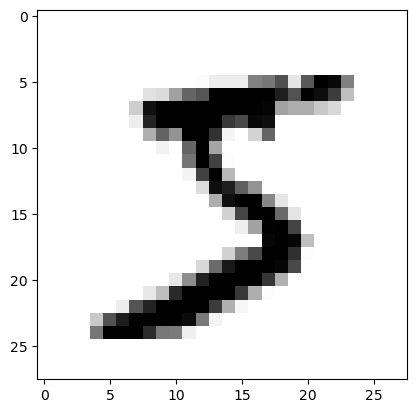

In [5]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"][:]
y = mnist["target"][:].astype(np.uint8)  # konverterar till int
print(X.shape)
print(y.shape)

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("Det sanna värdet för den printade bilden är", y[0])



## Kodblock 2 - Train/validation/test-split (testdata 20%)

In [6]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=14000, 
    random_state=42, 
    stratify=y
    )
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=14000, 
    random_state=42,
    stratify=y_train_val
    )

In [7]:
print("Train-fördelning:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nValidation-fördelning:")
print(pd.Series(y_val).value_counts(normalize=True).sort_index())

print("\nTest-fördelning:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


Train-fördelning:
0    0.098595
1    0.112548
2    0.099857
3    0.102024
4    0.097476
5    0.090190
6    0.098238
7    0.104167
8    0.097500
9    0.099405
Name: proportion, dtype: float64

Validation-fördelning:
0    0.098643
1    0.112500
2    0.099857
3    0.102000
4    0.097500
5    0.090143
6    0.098214
7    0.104214
8    0.097500
9    0.099429
Name: proportion, dtype: float64

Test-fördelning:
0    0.098643
1    0.112500
2    0.099857
3    0.102000
4    0.097500
5    0.090214
6    0.098214
7    0.104214
8    0.097500
9    0.099357
Name: proportion, dtype: float64


## Kodblock 3 - Skalning

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

## Kodblock 4 - Träning av modeller

In [9]:
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf)
]
voting_clf = VotingClassifier(named_estimators, voting='hard')

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]
for model in models:
    model.fit(X_train, y_train)
    
print("Accuracy för resp modell")
model_names = ["Logistic Regression", "Random Forest", "Extra Trees", "Voting Classifier"]
for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name:20s}:{score:.4f}")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Accuracy för resp modell
Logistic Regression :0.9099
Random Forest       :0.9666
Extra Trees         :0.9699
Voting Classifier   :0.9678


In [10]:
rows = []
for name, model in zip(model_names, models):
    y_pred = model.predict(X_val)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "F1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
        "Recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "Precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
    })

df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
df


,Model,Accuracy,F1_macro,F1_weighted,Recall_macro,Precision_macro
2,Extra Trees,0.969857,0.969703,0.969843,0.969691,0.969759
3,Voting Classifier,0.967786,0.967583,0.967763,0.967565,0.967673
1,Random Forest,0.966643,0.966433,0.966612,0.966448,0.966492
0,Logistic Regression,0.909929,0.908891,0.909819,0.908911,0.909080


## Kodblock 5 - Utvärdering av modeller

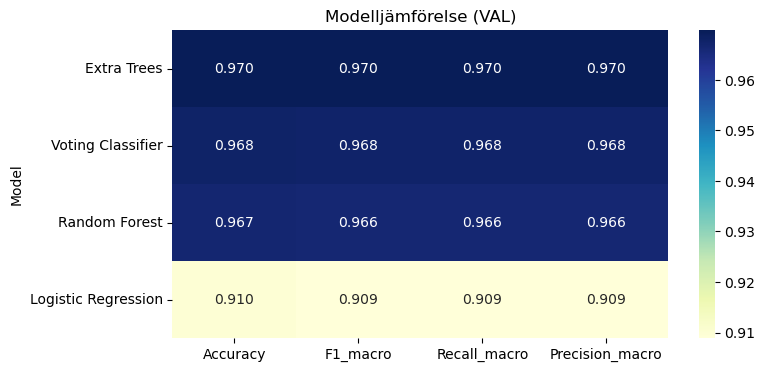

In [11]:
plt.figure(figsize=(8,4))
sns.heatmap(
    df.set_index("Model")[["Accuracy", "F1_macro", "Recall_macro", "Precision_macro"]],
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Modelljämförelse (VAL)")
plt.show()


# Prediktion på valideringsdata
et_pred_val = best_et.predict(X_val_s)

# Confusion matrix
cm = confusion_matrix(y_val, et_pred_val)
ConfusionMatrixDisplay(cm).plot()

## Kodblock 6 - GridSearch på vinnarmodell

In [12]:
param_grid = {
    "n_estimators": [200, 500],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 30],
    "min_samples_leaf": [1, 2]
}


In [13]:
grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_grid,
    scoring="f1_macro",   # bättre än accuracy för multi-class
    cv=3,
    n_jobs=-1,
    verbose=1
)


In [14]:
grid.fit(X_train_s, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,ExtraTreesCla...ndom_state=42)
,param_grid,"{'max_depth': [None, 30], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'n_estimators': [200, 500]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [15]:
print("Bästa parametrar:", grid.best_params_)
print("Bästa CV F1_macro:", grid.best_score_)


Bästa parametrar: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
Bästa CV F1_macro: 0.9688255662437745


## Kodblock 7 – Utvärdering av optimerad modell på VAL

In [16]:
best_et = grid.best_estimator_


              precision    recall  f1-score   support

           0     0.9799    0.9862    0.9830      1381
           1     0.9823    0.9867    0.9845      1575
           2     0.9573    0.9771    0.9671      1398
           3     0.9692    0.9489    0.9590      1428
           4     0.9763    0.9648    0.9705      1365
           5     0.9744    0.9651    0.9697      1262
           6     0.9770    0.9869    0.9819      1375
           7     0.9738    0.9685    0.9711      1459
           8     0.9633    0.9604    0.9618      1365
           9     0.9501    0.9576    0.9538      1392

    accuracy                         0.9704     14000
   macro avg     0.9703    0.9702    0.9703     14000
weighted avg     0.9705    0.9704    0.9704     14000



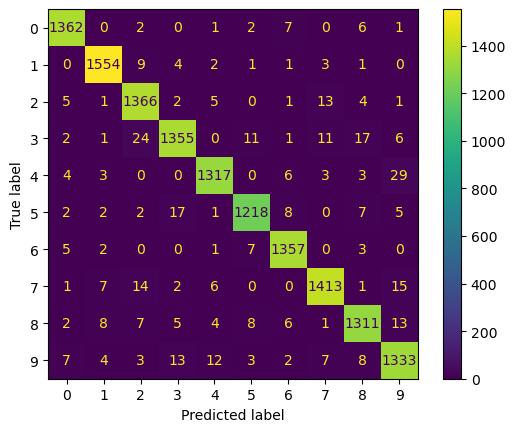

In [17]:
y_val_pred = best_et.predict(X_val_s)

print(classification_report(y_val, y_val_pred, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred)).plot()


## Kodblock 8 – Slutlig testutvärdering


FINAL TEST RESULT:
              precision    recall  f1-score   support

           0     0.9723    0.9913    0.9817      1381
           1     0.9829    0.9854    0.9841      1575
           2     0.9636    0.9649    0.9643      1398
           3     0.9640    0.9559    0.9599      1428
           4     0.9747    0.9597    0.9671      1365
           5     0.9712    0.9612    0.9662      1263
           6     0.9734    0.9847    0.9790      1375
           7     0.9717    0.9657    0.9687      1459
           8     0.9596    0.9568    0.9582      1365
           9     0.9408    0.9475    0.9441      1391

    accuracy                         0.9676     14000
   macro avg     0.9674    0.9673    0.9673     14000
weighted avg     0.9676    0.9676    0.9676     14000



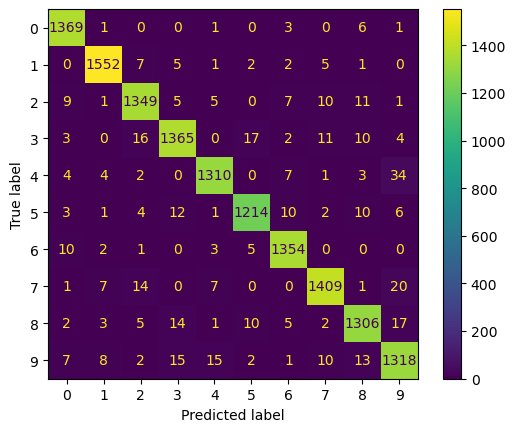

In [23]:
X_train_full_s = np.vstack([X_train_s, X_val_s])
y_train_full = np.hstack([y_train, y_val])

best_params = grid.best_params_.copy()
best_params["max_depth"] = 20
best_params["min_samples_leaf"] = 2

final_et = ExtraTreesClassifier(**best_params, random_state=42, n_jobs=-1)

final_et.fit(X_train_full_s, y_train_full)

y_test_pred = final_et.predict(X_test_s)

print("\nFINAL TEST RESULT:")
print(classification_report(y_test, y_test_pred, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred)).plot()


## Kodblock 9 - Sparar ned modellen

In [24]:


joblib.dump(final_et, "mnist_model.pkl")
joblib.dump(scaler, "mnist_scaler.pkl")

['mnist_scaler.pkl']

In [25]:
try:
    joblib.dump(final_et, "mnist_model.pkl")
    joblib.dump(scaler, "mnist_scaler.pkl")
    print("Nedsparat och klart! ✅")
except Exception as e:
    print("Något gick fel vid sparandet:")
    print(e)

Nedsparat och klart! ✅


In [21]:
import joblib
from sklearn.metrics import accuracy_score

model = joblib.load("mnist_model.pkl")
scaler = joblib.load("mnist_scaler.pkl")

# Testa om modellen verkar "förvänta sig" skalning eller inte:
y_pred_unscaled = model.predict(X_test)        # oskalat
y_pred_scaled   = model.predict(X_test_s)      # skalar som i din notebook (om du har X_test_s)

print("Acc (oskalerat):", accuracy_score(y_test, y_pred_unscaled))
print("Acc (skalat):  ", accuracy_score(y_test, y_pred_scaled))

Acc (oskalerat): 0.3673571428571429
Acc (skalat):   0.9712857142857143
